# ROOT

## Setting
Import the Python module for ROOT, and specify the path to the BNet file containing the Boolean model logic to be analyzed, as well as the directory where the results will be saved.

In [1]:
###############################################################################
######       In this cell, the user must input appropriate values.       ######
###############################################################################

#Add the path to the folder containing the modules of the ROOT framework to sys.path.
import sys, os

path_of_this_notebook = os.getcwd()
path_of_ROOT_framework = os.path.dirname(os.path.dirname(path_of_this_notebook))
# 'path_of_ROOT_framework' should direct the 'ROOT framework' folder. if not, please edit it manually.

sys.path.append(path_of_ROOT_framework)

In [2]:
#import python modules of ROOT

from Model_read_using_pyboolnet import read_pyboolnet_file
from iATG_module import iATG

In [3]:
###############################################################################
######       In this cell, the user must input appropriate values.       ######
###############################################################################

# the path to the .bnet file containing the logic of the model to the variables.

model_address = os.path.join(path_of_this_notebook, 'Enterocyte_differentiation_model_Boolean_logic.bnet')

## Determine transition-determining input configurations to analyze
Specify the input configurations to be analyzed.<br>
The input configuration before the irreversible process occurs is referred to as the basal input configuration ($IC_{basal}$), and the one that induces the irreversible process is referred to as the transition input configuration ($IC_{trans}$).<br><br>
For each node included in the input configuration, create a dictionary where the node is the key and the Boolean value it has in the basal input configuration is the value. Store this dictionary in a variable named `IC_basal`.<br>
Similarly, create a dictionary for the transition input configuration and store it in the variable `IC_transition`.

If mutations are to be incorporated into the model, the corresponding mutation information should be provided.<br>
Mutations can be represented as the fixation of specific nodes in the network model to either the ON (1) or OFF (0) state.<br>
This information should be entered into the `mutated_node_state_map` dictionary, where the key is the name of the mutated node and the value is the fixed Boolean state assigned to that node.

In [4]:
###############################################################################
######       In this cell, the user must input appropriate values.       ######
###############################################################################

IC_basal ={"FOXA2":1} 
IC_transition ={"FOXA2":0}
mutated_node_state_map = {}

## Construct an iATG
After creating the iATG and dynamics objects, perform the computation to construct the iATG by setting the appropriate parameter values.

In [5]:
dynamics_of_model = read_pyboolnet_file(model_address)
iATG_of_model = iATG(dynamics_of_model, IC_basal, IC_transition, mutated_node_state_map)

### Set the parameter values
- Set the parameter values required to compute the model’s iATG:
    - `use_all_initials`: Set this to either `True` or `False`.
        - If `True`, the attractor landscape for each input configuration is computed using all possible initial states of the Boolean model.
        - If `False`, only a subset of possible initial states is used to estimate the attractor landscape.
            - The calculation method of the approximated attractor landscape is explained in the Supplementary Materials
    - `waiting_number`: A positive integer.
        - Used _only_ when `use_all_initials` is `False`.
        - The larger this value is, the more initial states are used for attractor landscape estimation, resulting in higher estimation accuracy.
    - `difference_threshold`: A positive real number less than 1.
        - Used _only_ when `use_all_initials` is `False`.
        - The smaller this value is, the more initial states are used for attractor landscape estimation, improving accuracy.
    - `verbose`: Set this to either True or False.
        - When `use_all_initials` is `False`, setting `verbose` to `True` will display how many initial states are being explored during attractor landscape estimation.

In [6]:
###############################################################################
######       In this cell, the user must input appropriate values.       ######
###############################################################################

use_all_initials=True
waiting_number = 10000 #not used
difference_threshold = 0.0001 #not used
verbose=False

using these parameters, iATG of the model is constructed

In [7]:
iATG_of_model.calculate_attractor_landscapes_for_each_IC(use_all_initials,
                                                        waiting_number, 
                                                        difference_threshold,
                                                        verbose)
iATG_of_model.get_attractor_transitions_induced_by_IC_change_and_calculate_TPs()

Calculating attractor landscapes using all initial states.

Calculating attractor landscape on input configuration {'FOXA2': 1} using all initial states.
0.0% of all initial states are detected.
used time:  0.0
20.01953125% of all initial states are detected.
used time:  0.15259313583374023
40.0146484375% of all initial states are detected.
used time:  0.5881662368774414
60.009765625% of all initial states are detected.
used time:  1.1120758056640625
80.0048828125% of all initial states are detected.
used time:  1.637669324874878
time for Attractor landscape for IC {'FOXA2': 1}:  2.4844071865081787

Calculating attractor landscape on input configuration {'FOXA2': 0} using all initial states.
0.0% of all initial states are detected.
used time:  0.0
20.0439453125% of all initial states are detected.
used time:  0.13965320587158203
40.0146484375% of all initial states are detected.
used time:  0.4439272880554199
60.009765625% of all initial states are detected.
used time:  0.9007143974304

## Check the constructed iATG and select appropriate ITPs.
After inspecting the constructed iATG, examine the irreversible transition paths (ITPs) present in it.<br>By analyzing the phenotypes of the attractors that compose each ITP, select the ITPs that correspond to the observed irreversibile phenotypic change (OIPC).

### constructed iATG
The cell below displays the constructed iATG.<br>
Attractors included in the attractor landscape under the basal input configuration (`IC_basal`) are labeled with attractor codes in the form of `('basal', i)`, where `i` is an arbitrary index number.<br>
Attractors under the transition input configuration (`IC_transition`) are labeled as `('transition', i)`, where `i` is also an arbitrary index.<br><br>
An arrow between attractor codes (e.g., `('basal', 0) → ('transition', 1)`) indicates that if the model state remains at the attractor on the left (in this case, `('basal', 0)`), a transition to the attractor on the right (in this case, `('transition', 1)`) can occur upon a change in input configuration.

In [9]:
print("iATG constructed. \nthe edges in the iATG are as follows:")
for attractor_transition in iATG_of_model.attractor_transitions_induced_by_IC_change:
    print("{}->{}".format(attractor_transition[0],attractor_transition[1]))

iATG constructed. 
the edges in the iATG are as follows:
('basal', 0)->('transition', 0)
('basal', 1)->('transition', 0)
('basal', 2)->('transition', 8)
('basal', 3)->('transition', 8)
('basal', 4)->('transition', 3)
('basal', 5)->('transition', 3)
('basal', 6)->('transition', 13)
('basal', 7)->('transition', 13)
('basal', 8)->('transition', 2)
('basal', 9)->('transition', 2)
('basal', 10)->('transition', 7)
('basal', 11)->('transition', 7)
('basal', 12)->('transition', 0)
('basal', 13)->('transition', 0)
('basal', 14)->('transition', 8)
('basal', 15)->('transition', 8)
('basal', 16)->('transition', 2)
('basal', 17)->('transition', 2)
('basal', 18)->('transition', 3)
('basal', 19)->('transition', 3)
('basal', 20)->('transition', 13)
('basal', 21)->('transition', 13)
('basal', 22)->('transition', 7)
('basal', 23)->('transition', 7)
('basal', 24)->('transition', 0)
('basal', 25)->('transition', 3)
('basal', 26)->('transition', 0)
('basal', 27)->('transition', 3)
('transition', 0)->('basa

### Phenotype check of ITPs
Using the constructed iATG, irreversible transition paths (ITPs) present in the iATG can be identified.<br>
The ITPs that exist in this iATG are listed in the output of the following cell.



In [11]:
print("ITPs in the constructed iATG are as follows:")
ITP_index_map = {}
ITP_index = 0
iATG_of_model.find_iCAs_and_calculate_iCA_sizes()
for iCA in iATG_of_model.iCAs:
    iCA.search_ITPs()
    for ITP_of_model in iCA.ITPs:
        ITP_index_map[ITP_index] = ITP_of_model
        print("ITP index {}: {}".format(ITP_index, ITP_of_model))
        ITP_index += 1

ITPs in the constructed iATG are as follows:
ITP index 0: ITP from ('basal', 2) to ('transition', 8) to ('basal', 15)
ITP index 1: ITP from ('basal', 3) to ('transition', 8) to ('basal', 15)
ITP index 2: ITP from ('basal', 14) to ('transition', 8) to ('basal', 15)
ITP index 3: ITP from ('basal', 0) to ('transition', 0) to ('basal', 13)
ITP index 4: ITP from ('basal', 1) to ('transition', 0) to ('basal', 13)
ITP index 5: ITP from ('basal', 12) to ('transition', 0) to ('basal', 13)
ITP index 6: ITP from ('basal', 24) to ('transition', 0) to ('basal', 13)
ITP index 7: ITP from ('basal', 26) to ('transition', 0) to ('basal', 13)
ITP index 8: ITP from ('basal', 4) to ('transition', 3) to ('basal', 19)
ITP index 9: ITP from ('basal', 5) to ('transition', 3) to ('basal', 19)
ITP index 10: ITP from ('basal', 18) to ('transition', 3) to ('basal', 19)
ITP index 11: ITP from ('basal', 25) to ('transition', 3) to ('basal', 19)
ITP index 12: ITP from ('basal', 27) to ('transition', 3) to ('basal', 

Among the given ITPs, those corresponding to the observed irreversible phenotypic change (OIPC) should be selected for analysis.<br>
To do this, the average state information of the attractors that make up each ITP is utilized in this established model.

In [12]:
import pandas as pd

ITP_info_for_index = []
for index_of_ITP, ITP_of_model in ITP_index_map.items():
    ITP_info_for_index.append((index_of_ITP, str(ITP_of_model.attr_basal_irrev)))
    ITP_info_for_index.append((index_of_ITP, str(ITP_of_model.attr_transition)))
    ITP_info_for_index.append((index_of_ITP, str(ITP_of_model.attr_basal_rev)))


index_of_df = pd.MultiIndex.from_tuples(ITP_info_for_index, names=["ITP index", "attractor code"])

is_point_attractor = []
node_names_input_first = list(IC_basal.keys())
for node_name in dynamics_of_model.get_node_names():
    if node_name not in node_names_input_first:
        node_names_input_first.append(node_name)
node_averagestates_map = {node_name:[] for node_name in node_names_input_first}
for index_of_ITP, attractor_code in ITP_info_for_index:
    attractor_code = eval(attractor_code)#str to tuple
    attractor_object = iATG_of_model.get_attractor_using_attr_tuple_form(attractor_code)
    average_state = attractor_object.get_average_state()
    is_point_attractor.append(attractor_object.is_point_attractor())
    for node_name, list_of_average_states in node_averagestates_map.items():
        average_state_of_node = average_state.get(node_name, None)
        list_of_average_states.append(average_state_of_node)

df_for_ITP_info = pd.DataFrame({"is point attractor":is_point_attractor, **node_averagestates_map}, 
                               index=index_of_df)

The `df_for_ITP_info` calculated in the cell above contains the average state information of attractors included in each ITP.<br>
Among the rows with the same ITP index value, 
- the first row shows the average state of the attractor corresponding to the ITP's first attractor, 
- the second row corresponds to the second attractor of the ITP, 
- and the third row corresponds to the third (final) attractor of the ITP.

<br>The values of `df_for_ITP_info` are displayed in the output of the cell below.

In [13]:
print("The average state for each attractor in ITPs")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df_for_ITP_info)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

The average state for each attractor in ITPs


is point attractor  FOXA2  ARID5B  CBX3  \
ITP index attractor code                                                
0         ('basal', 2)                      True    1.0     0.0   1.0   
          ('transition', 8)                 True    0.0     1.0   1.0   
          ('basal', 15)                     True    1.0     1.0   1.0   
1         ('basal', 3)                      True    1.0     1.0   1.0   
          ('transition', 8)                 True    0.0     1.0   1.0   
          ('basal', 15)                     True    1.0     1.0   1.0   
2         ('basal', 14)                     True    1.0     0.0   1.0   
          ('transition', 8)                 True    0.0     1.0   1.0   
          ('basal', 15)                     True    1.0     1.0   1.0   
3         ('basal', 0)                      True    1.0     0.0   0.0   
          ('transition', 0)                 True    0.0     1.0   0.0   
          ('basal', 13)                     True    1.0     1.0   0.0   
4         ('basal', 1)                      True    1.0     1.0   0.0   
          ('transition', 0)                 True    0.0     1.0   0.0   
          ('basal', 13)                     True    1.0     1.0   0.0   
5         ('basal', 12)                     True    1.0     0.0   0.0   
          ('transition', 0)                 True    0.0     1.0   0.0   
          ('basal', 13)                     True    1.0     1.0   0.0   
6         ('basal', 24)                     True    1.0     1.0   0.0   
          ('transition', 0)                 True    0.0     1.0   0.0   
          ('basal', 13)                     True    1.0     1.0   0.0   
7         ('basal', 26)                     True    1.0     1.0   0.0   
          ('transition', 0)                 True    0.0     1.0   0.0   
          ('basal', 13)                     True    1.0     1.0   0.0   
8         ('basal', 4)                     False    1.0     0.0   0.0   
          ('transition', 3)                 True    0.0     1.0   0.0   
          ('basal', 19)                    False    1.0     1.0   0.0   
9         ('basal', 5)                     False    1.0     1.0   0.0   
          ('transition', 3)                 True    0.0     1.0   0.0   
          ('basal', 19)                    False    1.0     1.0   0.0   
10        ('basal', 18)                    False    1.0     0.0   0.0   
          ('transition', 3)                 True    0.0     1.0   0.0   
          ('basal', 19)                    False    1.0     1.0   0.0   
11        ('basal', 25)                    False    1.0     1.0   0.0   
          ('transition', 3)                 True    0.0     1.0   0.0   
          ('basal', 19)                    False    1.0     1.0   0.0   
12        ('basal', 27)                    False    1.0     1.0   0.0   
          ('transition', 3)                 True    0.0     1.0   0.0   
          ('basal', 19)                    False    1.0     1.0   0.0   
13        ('basal', 6)                     False    1.0     0.0   1.0   
          ('transition', 13)               False    0.0     1.0   1.0   
          ('basal', 21)                    False    1.0     1.0   1.0   
14        ('basal', 7)                     False    1.0     1.0   1.0   
          ('transition', 13)               False    0.0     1.0   1.0   
          ('basal', 21)                    False    1.0     1.0   1.0   
15        ('basal', 20)                    False    1.0     0.0   1.0   
          ('transition', 13)               False    0.0     1.0   1.0   
          ('basal', 21)                    False    1.0     1.0   1.0   
16        ('basal', 8)                      True    1.0     0.0   1.0   
          ('transition', 2)                 True    0.0     1.0   1.0   
          ('basal', 17)                     True    1.0     1.0   1.0   
17        ('basal', 9)                      True    1.0     1.0   1.0   
          ('transition', 2)                 True    0.0     1.0   1.0   
          ('bas

### Selection of appropriate ITPs
You can add the `ITP index` of the ITPs you want to analyze by using the `append` method on `ITP_indices_to_analyze` in the cell directly below.<br>
Irreversibility kernel and reversion control method searches will then be performed on the selected ITPs.

The criteria for selecting ITPs are left to the user.<br>
In the analysis of data-driven models, we employed a clustering approach to classify ITPs. Among the classified ITP clusters, we selected the cluster whose relative changes in phenotype scores across the attractors composing the ITPs most closely resembled the relative phenotype score changes in the cellular irreversible process under investigation, and selected the ITPs belonging to that cluster.

If you wish to examine all constituent states of an attractor (rather than its average state), you can use:
`iATG_of_model.get_attractor_using_attr_tuple_form(attractor_code).show_states()`<br>
This command will display the constituent states of the attractor corresponding to the given attractor_code (which is a tuple type).

In [45]:
df_for_ITP_info.to_csv(os.path.join(path_of_this_notebook,'ITPs_Colon.csv'))

In [ ]:
df = pd.read_csv(os.path.join(path_of_this_notebook,'ITPs_Colon.csv'))

To compute the phenotype scores, we used the following components as markers.

In [17]:
stem_markers = ['ARID5B','HDAC2','PROX1','MYB','NR4A2','FOXA2','SPDEF','CBX3','FOXM1']
entero_markers = ["PRDM1","MXI1","SMAD3"]

Using these markers, we calculated the changes (Delta) in stem scores and differentiation scores for each ITP.

In [26]:
df['stem_score'] = df[stem_markers].mean(axis=1)
df['entero_score'] = df[entero_markers].mean(axis=1)

In [ ]:
df = df.sort_values(['ITP index']).reset_index(drop=True)
df['step'] = df.groupby('ITP index').cumcount()

# 1) Pivot to wide format: make steps 0, 1, 2 into columns
wide = df.pivot_table(index='ITP index', columns='step', values=['stem_score','entero_score'])

# 2) Compute the changes
change_df = pd.DataFrame({
    'Delta Stem (Forward)': wide['stem_score'][1] - wide['stem_score'][0],
    'Delta Stem (Backward)' : wide['stem_score'][2] - wide['stem_score'][0],
    'Delta Diff (Forward)': wide['entero_score'][1] - wide['entero_score'][0],
    'Delta Diff (Backrward)' : wide['entero_score'][2] - wide['entero_score'][0],
}).reset_index()

print(change_df.head())

   ITP index  Delta Stem (Forward)  Delta Stem (Backward)  \
0          0             -0.111111               0.111111   
1          1             -0.222222               0.000000   
2          2             -0.111111               0.111111   
3          3             -0.111111               0.111111   
4          4             -0.222222               0.000000   

   Delta Diff (Forward)  Delta Diff (Backrward)  
0              0.333333                0.333333  
1              0.333333                0.333333  
2              0.000000                0.000000  
3              0.333333                0.333333  
4              0.333333                0.333333  


The following library was used for clustering.

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import fcluster
from matplotlib.patches import Patch

The clustering procedure is as follows:

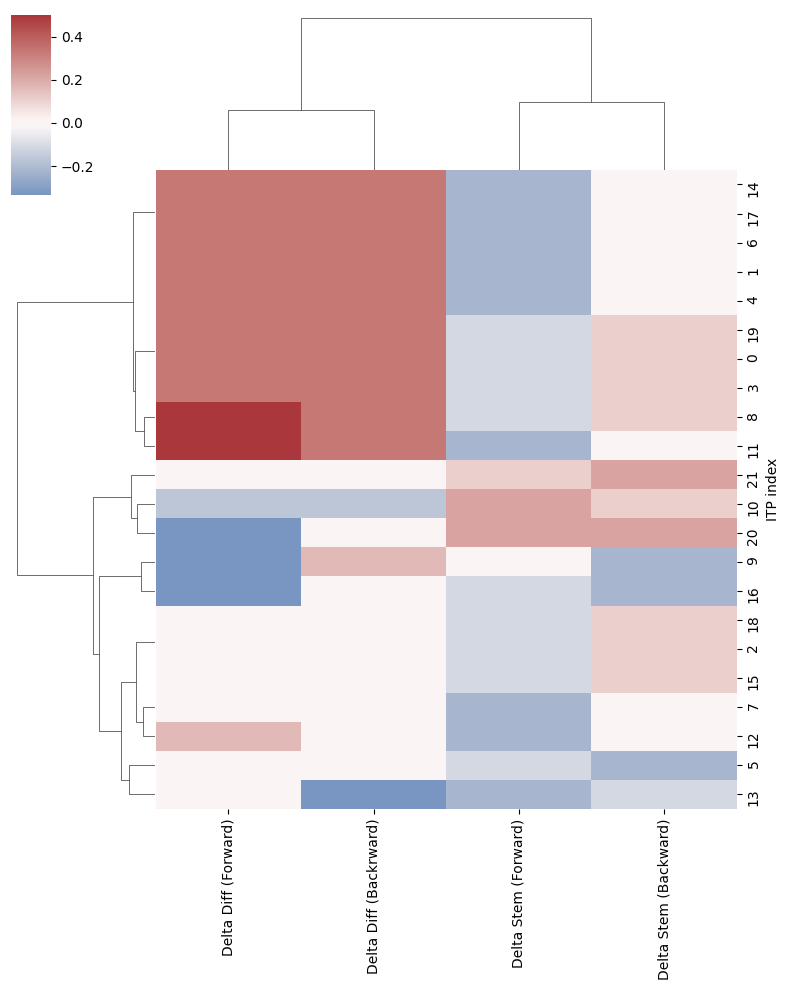

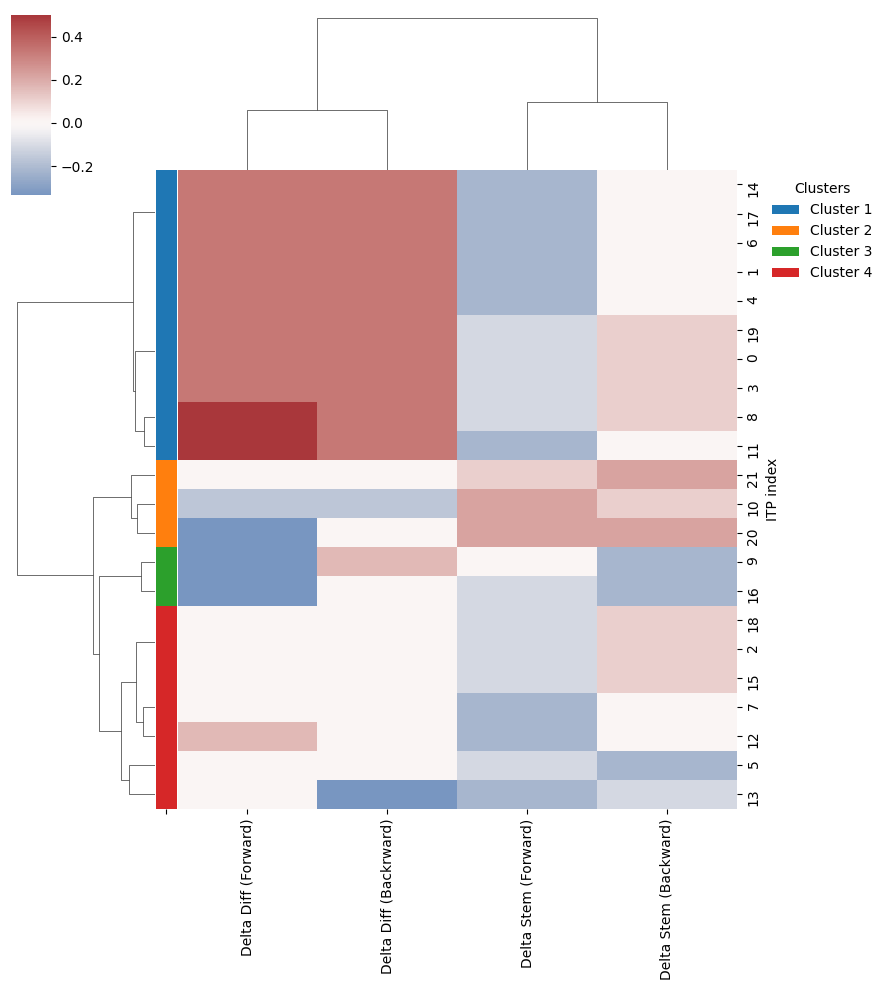

In [ ]:
# 0) Extract only numerical columns
features = change_df.drop(columns=['ITP index'])
features.index = change_df['ITP index']

# 1) Run clustermap
g = sns.clustermap(
    features,
    method='ward',
    metric='euclidean',
    cmap='vlag',
    center=0,
    figsize=(8, 10)
)

# 2) Extract cluster labels using linkage (in here, 4 clusters)
linkage_matrix = g.dendrogram_row.linkage
cluster_labels = fcluster(linkage_matrix, t=4, criterion='maxclust')

# 3) Add cluster labels to change_df (mapped by ITP index)
itp_to_cluster = dict(zip(features.index, cluster_labels))
change_df['cluster'] = change_df['ITP index'].map(itp_to_cluster)

# 4) Prepare row_colors (cluster color bar)
uniq = sorted(set(cluster_labels))
palette = sns.color_palette("tab10", len(uniq))
cmap_dict = dict(zip(uniq, palette))
row_colors = pd.Series(change_df['cluster'].values, index=change_df['ITP index']).map(cmap_dict)

# 5) Generate the final clustermap with row_colors
g = sns.clustermap(
    features,
    method='ward',
    metric='euclidean',
    cmap='vlag',
    center=0,
    row_colors=row_colors,
    figsize=(8, 10)
)

# 6) Add a legend (for row_colors)
handles = [Patch(facecolor=cmap_dict[c], label=f'Cluster {c}') for c in uniq]
# The legend can be attached either to the heatmap axis
# or as a figure-level legend. Use one of the two options.
g.ax_heatmap.legend(handles=handles, title="Clusters",
                    loc='upper left', bbox_to_anchor=(1.04, 1.0), frameon=False)
# Alternative: g.fig.legend(handles=handles, title="Clusters", loc='upper right', bbox_to_anchor=(1.15, 1.0), frameon=False)

plt.show()

Among the four identified ITP clusters, we selected cluster 1,
which shows relatively high Delta(Δ) Diff (Forward) and Delta(Δ) Diff (Backward),
and relatively low Delta(Δ) Stem (Forward) and Delta(Δ) Stem (Backward).

The ITP indices included in cluster 1 are as follows:

In [30]:
cluster_members = (change_df
                   .sort_values(['cluster','ITP index'])
                   .groupby('cluster')['ITP index']
                   .apply(list))
print(cluster_members[1])

[0, 1, 3, 4, 6, 8, 11, 14, 17, 19]


In [31]:
###############################################################################
######       In this cell, the user must input appropriate values.       ######
###############################################################################

ITP_indices_to_analyze = [] # <- append the ITP indices matching the OIPC here.
ITP_indices_to_analyze.extend(cluster_members[1])

## Analysis of selected ITPs
For each selected ITP, the irreversibility kernel is analyzed. The irreversibility kernel consists of irreversibility motifs—formed by positive feedback loops—and their corresponding coherency conditions, which stabilize each motif at the final attractor of the ITP.

Using the irreversibility kernels identified for each ITP, control strategies are subsequently explored.

### Setting feedback length for irreversibility kernel construction
In the cell below, set the value of `max_len_of_feedback_search`.<br>
This parameter determines the maximum length of positive feedback loops (in the expanded network) to be searched as candidates for the irreversibility kernel.

- If `max_len_of_feedback_search` is set to 0, the search is conducted without any length limit.

- If it is set to a positive integer, only positive feedback loops with a length less than or equal to that number will be considered.

When the network has many nodes and dense connectivity, an unrestricted search can result in excessive computational cost. Therefore, it is recommended to set this value based on the available computational resources and time constraints.

In [32]:
###############################################################################
######       In this cell, the user must input appropriate values.       ######
###############################################################################

max_len_of_feedback_search = 0

### Analysis and visualization of the irreversibility kernel
Perform the irreversibility kernel analysis for each ITP.

In [33]:

for ITP_index in ITP_indices_to_analyze:
    ITP_object = ITP_index_map[ITP_index]
    
    # initialize the irreversibility motifs and coherency conditions in this object.
    # when you run this code more than once, you may want to clear the previous results.
    ITP_object.reset_the_info_of_irreversibility_kernel()
    
    ITP_object.find_irreversibility_kernel(max_len_of_feedback_search)

Store the results of the irreversibility kernel analysis in `df_irreversibility_kernel`.

In [34]:
ITP_indices = []
column_for_irreversibilty_motifs = []
column_for_coherency_conditions = []

for ITP_index in ITP_indices_to_analyze:
    ITP_object = ITP_index_map[ITP_index]
    for i, irreversibility_motif in enumerate(ITP_object.irreversibility_motifs):
        corresponding_coherency_condition = ITP_object.coherency_conditions[i]

        ITP_indices.append(ITP_index)
        column_for_irreversibilty_motifs.append(irreversibility_motif)
        column_for_coherency_conditions.append(corresponding_coherency_condition)

df_irreversibility_kernel = pd.DataFrame({"irreversibility motif":column_for_irreversibilty_motifs,
                                           "coherency condition":column_for_coherency_conditions},
                                          index=ITP_indices)
df_irreversibility_kernel.index.name = 'ITP index'

Structure of `df_irreversibility_kernel` is as follows.

Each row in `df_irreversibility_kernel` represents one irreversibility motif and its corresponding coherency condition for the ITP identified by the `ITP index` in that row.<br>
Since a single irreversibility kernel can consist of multiple irreversibility motifs and their corresponding coherency conditions, multiple rows can share the same ITP index.

- The `irreversibility motif` column lists the nodes that make up the irreversibility motif. In the network model’s structure, the subnetwork formed by these nodes contains combinations of positive feedbacks that constitute the irreversibility motif.
- The `coherency condition` column specifies the condition under which the `irreversibility motif` in the same row remains stable in the final attractor of the ITP. This is expressed as a dictionary where each key represents a node, and its value indicates the Boolean state that the node must maintain to satisfy the coherency condition.

In [35]:
print("Irreversibiltiy kernel for each ITP")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df_irreversibility_kernel)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

Irreversibiltiy kernel for each ITP


,irreversibility motif,coherency condition
ITP index,,
0,{ARID5B},{}
0,{SMAD3},{}
1,{SMAD3},{}
3,{ARID5B},{}
3,{SMAD3},{}
4,{SMAD3},{}
6,{SPDEF},{}
6,{SMAD3},{}
8,{ARID5B},{}


We then calculate inclusion ratios. The inclusion ratios are the proportions with which each node appears in the irreversibility kernels of the selected ITPs.

In [36]:
all_nodes_in_irreversibility_kernel = set()
num_of_motifs = 0
num_of_kernels = 0

for ITP_index in ITP_indices_to_analyze:
    ITP_object = ITP_index_map[ITP_index]
    
    if ITP_object.irreversibility_motifs:
        num_of_kernels += 1
        num_of_motifs += len(ITP_object.irreversibility_motifs)
    
    for i, irreversibility_motif in enumerate(ITP_object.irreversibility_motifs):
        corresponding_coherency_condition = ITP_object.coherency_conditions[i]

        all_nodes_in_irreversibility_kernel.update(irreversibility_motif)
        all_nodes_in_irreversibility_kernel.update(corresponding_coherency_condition)

all_nodes_in_irreversibility_kernel = list(all_nodes_in_irreversibility_kernel)
all_nodes_in_irreversibility_kernel.sort()

kernel_level_inclusion_ratios = []
motif_level_inclusion_ratios = []
condition_level_inclusion_ratios = []

for node_name in all_nodes_in_irreversibility_kernel:
    motif_contatinment = 0
    condition_contatinment = 0
    kernel_contatinment = 0
    
    for ITP_index in ITP_indices_to_analyze:
        ITP_object = ITP_index_map[ITP_index]
        kernel_contatiment_flag = False
        
        for i, irreversibility_motif in enumerate(ITP_object.irreversibility_motifs):
            corresponding_coherency_condition = ITP_object.coherency_conditions[i]

            if node_name in irreversibility_motif:
                motif_contatinment += 1
                kernel_contatiment_flag = True
            if node_name in corresponding_coherency_condition:
                condition_contatinment += 1
                kernel_contatiment_flag = True

        if kernel_contatiment_flag:
            kernel_contatinment += 1

    kernel_level_inclusion_ratios.append(kernel_contatinment/num_of_kernels)
    motif_level_inclusion_ratios.append(motif_contatinment/num_of_motifs)
    condition_level_inclusion_ratios.append(condition_contatinment/num_of_motifs)

df_inclusion_ratios = pd.DataFrame({"Kernel-inclusion ratio":kernel_level_inclusion_ratios},
                                    index=all_nodes_in_irreversibility_kernel)      


`Kernel-inclusion ratio` indicates how often a given node appears in the irreversibility kernels of the analyzed ITPs. A value of 1 means that the node is included in the irreversibility kernels of all ITPs considered. In such cases, the node may be part of the irreversibility motif, the coherency condition, or both.

In [37]:
print("inclusion ratios in irreversibility kernel")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df_inclusion_ratios)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

inclusion ratios in irreversibility kernel


,Kernel-inclusion ratio
ARID5B,0.4
SMAD3,1.0
SPDEF,0.2


## Control strategies using the irreversibility kernel
For each ITP, control strategies for 'resetting control' and 'reversing control' are computed using the corresponding irreversibility kernel.<br>
Each control strategy consists of a subset of nodes from the irreversibility motif (referred to as control targets) and the assigned states for each control target.

The cells below compute control strategies in which the number of control target nodes is equal to `num_of_control_targets`.<br>
If the control targets consist of nodes 'N1', 'N2', ..., 'Ni', and the assigned states are x1, x2, ..., xi, respectively, then the control strategy is represented as a dictionary: {'N1': x1, 'N2': x2, ..., 'Ni': xi}.<br>
For each ITP under analysis, candidate control strategies (control candidates) are calculated and stored in `ITPindex_controlcandidate_map`, with the ITP index as the key and the corresponding control strategies as the value.

ROOT utilizes these control candidates to propose the most appropriate ones (superior control strategies) for either resetting control or reversibility-inducing control.

In [38]:
###############################################################################
######       In this cell, the user must input appropriate values.       ######
###############################################################################

num_of_control_targets = 1

In [39]:
import pandas as pd

ITPindex_controlcandidate_map = {}
ITP_indices = []
control_candidates_for_each_ITP_index = []

for ITP_index in ITP_indices_to_analyze:
    ITP_object = ITP_index_map[ITP_index]
    control_candidates_for_the_ITP = ITP_object.get_control_candidates_having_n_control_targets(num_of_control_targets)
    ITPindex_controlcandidate_map[ITP_index] = control_candidates_for_the_ITP
    for control_candidate_for_the_ITP in control_candidates_for_the_ITP:
        ITP_indices.append(ITP_index)
        control_candidates_for_each_ITP_index.append(control_candidate_for_the_ITP)

df_control_candidates = pd.DataFrame({"control candidate":control_candidates_for_each_ITP_index},
                                      index=ITP_indices)
df_control_candidates.index.name = 'ITP index'

print("control candidates per ITP")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df_control_candidates)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

control candidates per ITP


,control candidate
ITP index,
1,{'SMAD3': 0}
4,{'SMAD3': 0}
14,{'SMAD3': 0}
17,{'SMAD3': 0}


ROOT proposes two approaches to utilize the derived control candidates for control. These two approaches are as follows:
- resetting control
- reversing control

### Resetting control

The objective of the resetting control is as follows:
- When the model state resides in the final attactor of the target ITP,
- Without altering the model’s inherent dynamics permanently,
- Guide the model state toward the first attractor of the corresponding ITP.

The resetting control procedure is carried out in the following steps:
- First, fix the control targets to their assigned state values of the given control strategy.
- Then, allow the model state to converge to a new attractor under the dynamics with the control strategy applied.
- After convergence, release the fixation of the control targets.
- Finally, the model state will transition to one of the attractors that exist in the original (uncontrolled) dynamics.

Each control strategy is associated with a 'resetting efficacy score', which indicates the likelihood of achieving the goal of resetting control.<br>
ROOT assumes that, among all control strategies with the same number of control targets, those with the highest resetting efficacy score are most likely to be included among the control candidates.<br>
Based on this assumption, ROOT calculates the resetting efficacy score for each control strategy among the control candidates and uses these values to identify the superior control strategies for resetting control.

The cell below displays a table that ranks, for each ITP, the control strategies in the control candidates by their resetting efficacy scores in descending order. For each ITP, the control strategies with rank 1 are those proposed by ROOT as the superior for resetting control.

In [40]:
def compute_ranks(values):
    indexed = list(enumerate(values))
    sorted_indexed = sorted(indexed, key=lambda x: -x[1])

    ranks = [0] * len(values)
    rank = 1
    for i, (idx, val) in enumerate(sorted_indexed):
        if i > 0 and val != sorted_indexed[i - 1][1]:
            rank = i + 1
        ranks[idx] = rank

    return ranks

control_strategies_for_all_analyzed_ITPs = []
for control_strategies in ITPindex_controlcandidate_map.values():
    for control_strategy in control_strategies:
        if control_strategy not in control_strategies_for_all_analyzed_ITPs:
            control_strategies_for_all_analyzed_ITPs.append(control_strategy)

index_of_df = []
control_strategies_in_df = []
control_strategy_is_in_candidate = []
resetting_efficacy_scores_in_df = []
rank_in_the_ITP = []

for ITP_index, control_strategies_in_candidate in ITPindex_controlcandidate_map.items():
    ITP_object = ITP_index_map[ITP_index]
    resetting_efficacy_scores_for_each_ITP = []
    for control_strategy in control_strategies_for_all_analyzed_ITPs:
        index_of_df.append(ITP_index)
        control_strategies_in_df.append(control_strategy)
        if control_strategy in control_strategies_in_candidate:
            control_strategy_is_in_candidate.append(True)
        else:
            control_strategy_is_in_candidate.append(False)
        resetting_efficacy_score = ITP_object.get_resetting_efficacy_score_of(control_strategy)
        resetting_efficacy_scores_for_each_ITP.append(resetting_efficacy_score)
    resetting_efficacy_scores_in_df.extend(resetting_efficacy_scores_for_each_ITP)
    
    rank_for_each_ITP = compute_ranks(resetting_efficacy_scores_for_each_ITP)
    rank_in_the_ITP.extend(rank_for_each_ITP)

df_resetting_control = pd.DataFrame({"control strategy":control_strategies_in_df,
                                     "control strategy is candidate control for the ITP":control_strategy_is_in_candidate,
                                       "resetting efficacy score":resetting_efficacy_scores_in_df,
                                       "rank in the ITP":rank_in_the_ITP},
                                      index=index_of_df)
df_resetting_control.index.name = 'ITP index'
df_resetting_control = df_resetting_control.sort_values(by=["ITP index", "resetting efficacy score", "rank in the ITP"], 
                                                        ascending=[True, False,True])

print("control strategies and their resetting efficacy scores per ITP")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df_resetting_control)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

control strategies and their resetting efficacy scores per ITP


,control strategy,control strategy is candidate control for the ITP,resetting efficacy score,rank in the ITP
ITP index,,,,
0,{'SMAD3': 0},False,0.0,1
1,{'SMAD3': 0},True,1.0,1
3,{'SMAD3': 0},False,0.0,1
4,{'SMAD3': 0},True,1.0,1
6,{'SMAD3': 0},False,0.0,1
8,{'SMAD3': 0},False,0.0,1
11,{'SMAD3': 0},False,0.0,1
14,{'SMAD3': 0},True,1.0,1
17,{'SMAD3': 0},True,1.0,1


The following table shows the average resetting efficacy score for each control configuration, the ratios with which each was selected as a candidate control across ITPs, and their rank based on the average resetting efficacy scores. When attempting to apply resetting control across multiple ITPs simultaneously, the control strategies ranked 1 are those recommended by ROOT as the superior one.

In [41]:
resetting_efficacy_scores_averaged = []
ratios_of_being_candidate_control = []
average_ranks = []
for control_strategy in control_strategies_for_all_analyzed_ITPs:
    sub_df_for_the_control_strategy = df_resetting_control[df_resetting_control["control strategy"] == control_strategy]
    resetting_efficacy_score_averaged_of_the_control_configuration = sub_df_for_the_control_strategy["resetting efficacy score"].mean()
    resetting_efficacy_scores_averaged.append(resetting_efficacy_score_averaged_of_the_control_configuration)
    ratio_of_being_condidate_for_the_control_strategy = sub_df_for_the_control_strategy["control strategy is candidate control for the ITP"].mean()
    ratios_of_being_candidate_control.append(ratio_of_being_condidate_for_the_control_strategy)
    average_ranks = compute_ranks(resetting_efficacy_scores_averaged)

df_resetting_control_statistic = pd.DataFrame({"average of resetting efficacy scores":resetting_efficacy_scores_averaged,
                                     "ratio of being candidate control":ratios_of_being_candidate_control,
                                     "average rank":average_ranks},
                                      index=control_strategies_for_all_analyzed_ITPs)
df_resetting_control_statistic.index.name = 'control strategy'

df_resetting_control_statistic = df_resetting_control_statistic.sort_values("average rank")

print("Summary of averaged resetting efficacy scores and ratios of being candidate control")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df_resetting_control_statistic)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

Summary of averaged resetting efficacy scores and ratios of being candidate control


,average of resetting efficacy scores,ratio of being candidate control,average rank
control strategy,,,
{'SMAD3': 0},0.4,0.4,1


In the following cell, we compare all control strategies that have the same number of control targets with the control strategies identified by ROOT through the control candidates, using their resetting efficacy scores.

This calculation is intended to evaluate the performance of ROOT.

In [42]:
import itertools
num_of_control_targets = 1

ITPindex_allcontrolstrategies_map = {}

def generate_dicts_from_combos(combo, ITP_object):
    all_dicts = []
    in_S = [node for node in combo if node in ITP_object.non_cyclic_part_basal_rev]
    not_in_S = [node for node in combo if node not in ITP_object.non_cyclic_part_basal_rev]

    for values in itertools.product([1, 0], repeat=len(not_in_S)):
        d = {node: 1-ITP_object.non_cyclic_part_basal_rev[node] for node in in_S}
        d.update({node: val for node, val in zip(not_in_S, values)})
        all_dicts.append(d)

    return all_dicts

for ITP_index in ITP_indices_to_analyze:
    ITP_object = ITP_index_map[ITP_index]
    all_control_strategies = []
    node_names = ITP_object.iCA.iATG.dynamics_Boolean_net.get_node_names()
    for node_comb in itertools.combinations(node_names, r=num_of_control_targets):
        all_control_strategies.extend(generate_dicts_from_combos(node_comb, ITP_object))
    ITPindex_allcontrolstrategies_map[ITP_index] = all_control_strategies

index_of_df = []
control_strategies_in_df = []
does_control_strategy_come_from_candidate = []
resetting_efficacy_scores_in_df = []
rank_in_the_ITP = []

for ITP_index, all_control_strategies in ITPindex_allcontrolstrategies_map.items():
    ITP_object = ITP_index_map[ITP_index]
    resetting_efficacy_scores_for_each_ITP = []
    for control_strategy in all_control_strategies:
        index_of_df.append(ITP_index)
        control_strategies_in_df.append(control_strategy)
        resetting_efficacy_score = ITP_object.get_resetting_efficacy_score_of(control_strategy)
        resetting_efficacy_scores_for_each_ITP.append(resetting_efficacy_score)
        if control_strategy in ITPindex_controlcandidate_map[ITP_index]:
            does_control_strategy_come_from_candidate.append(True)
        else:
            does_control_strategy_come_from_candidate.append(False)
    
    resetting_efficacy_scores_in_df.extend(resetting_efficacy_scores_for_each_ITP)
    rank_for_each_ITP = compute_ranks(resetting_efficacy_scores_for_each_ITP)
    rank_in_the_ITP.extend(rank_for_each_ITP)

df_resetting_control_all = pd.DataFrame({"control strategy":control_strategies_in_df,
                                        "is derived from ROOT":does_control_strategy_come_from_candidate,
                                       "resetting efficacy scores":resetting_efficacy_scores_in_df,
                                       "rank in the ITP":rank_in_the_ITP},
                                      index=index_of_df)
df_resetting_control_all.index.name = 'ITP index'
df_resetting_control_all = df_resetting_control_all.sort_values(by=["ITP index", "resetting efficacy scores", "rank in the ITP"], 
                                                                ascending=[True, False,True])

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df_resetting_control_all)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

,control strategy,is derived from ROOT,resetting efficacy scores,rank in the ITP
ITP index,,,,
0,{'ARID5B': 0},False,0.0,1
0,{'CBX3': 0},False,0.0,1
0,{'CREB3L1': 0},False,0.0,1
0,{'FOXA2': 0},False,0.0,1
0,{'FOXM1': 1},False,0.0,1
0,{'HDAC2': 1},False,0.0,1
0,{'MXI1': 0},False,0.0,1
0,{'MYB': 0},False,0.0,1
0,{'NR4A2': 0},False,0.0,1


If we compute the average resetting efficacy score across the selected ITPs for all control strategies and then determine their ranks, the results are as follows.

This calculation is also intended to evaluate the performance of ROOT.

In [43]:
all_control_strategies = []
for control_strategies in ITPindex_allcontrolstrategies_map.values():
    for control_strategy in control_strategies:
        if control_strategy not in all_control_strategies:
            all_control_strategies.append(control_strategy)

does_it_come_from_ROOT = []
for control_strategy in all_control_strategies:
    flag = False
    for control_candidates in ITPindex_controlcandidate_map.values():
        if control_strategy in control_candidates:
            flag = True
            break
    does_it_come_from_ROOT.append(flag)

resetting_efficacy_score_averaged_all = []
for control_strategy in all_control_strategies:
    resetting_efficacy_scores_for_each_ITP = []
    for ITP_index in ITPindex_allcontrolstrategies_map:
        ITP_object = ITP_index_map[ITP_index]
        resetting_efficacy_score_for_control_strategy = ITP_object.get_resetting_efficacy_score_of(control_strategy)
        resetting_efficacy_scores_for_each_ITP.append(resetting_efficacy_score_for_control_strategy)
    reversing_efficacy_score_averaged_of_the_control_strategy = sum(resetting_efficacy_scores_for_each_ITP)/len(resetting_efficacy_scores_for_each_ITP)
    resetting_efficacy_score_averaged_all.append(reversing_efficacy_score_averaged_of_the_control_strategy)

ranks_averaged = compute_ranks(resetting_efficacy_score_averaged_all)

df_resetting_control_all_averaged_statistic = pd.DataFrame({"average of resetting efficacy score":resetting_efficacy_score_averaged_all,
                                     "is derived from ROOT":does_it_come_from_ROOT,
                                     "average rank":ranks_averaged},
                                      index=all_control_strategies)
df_resetting_control_all_averaged_statistic.index.name = 'control strategy'
df_resetting_control_all_averaged_statistic = df_resetting_control_all_averaged_statistic.sort_values("average rank")

print("Summary of averaged resetting efficacy score of all control strategies")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df_resetting_control_all_averaged_statistic)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

Summary of averaged resetting efficacy score of all control strategies


,average of resetting efficacy score,is derived from ROOT,average rank
control strategy,,,
{'SMAD3': 0},0.4,True,1
{'ARID5B': 0},0.0,False,2
{'MXI1': 1},0.0,False,2
{'MYB': 1},0.0,False,2
{'CBX3': 1},0.0,False,2
{'SPDEF': 1},0.0,False,2
{'PROX1': 0},0.0,False,2
{'PRDM1': 1},0.0,False,2
{'NR4A2': 0},0.0,False,2
